# Домашняя работа: NLP Transformer с нуля на PyTorch

В этой домашней работе вы реализуете основные компоненты Transformer для обработки текста:

- character-level токенизацию;
- token embeddings;
- positional embeddings;
- scaled dot-product attention;
- multi-head self-attention;
- causal mask;
- Transformer block;
- decoder-only MiniGPT;
- генерацию текста.


In [79]:
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from IPython.display import HTML, display
from torch import nn


DEVICE = (
  "cuda"
  if torch.cuda.is_available()
  else "mps"
  if torch.backends.mps.is_available()
  else "cpu"
)
print("DEVICE:", DEVICE)

torch.manual_seed(37)
random.seed(37)

DEVICE: cpu


## 1. Данные

Ниже есть предзаполненный text, на котором можно обучать трансформер, однако, будет гораздо интереснее, если используете свой текст
Модель будет учиться предсказывать следующий символ.


In [80]:
text = """
#pragma once

#include "utils.hpp"

// MARK: Concepts

template <typename vert_t>
concept AllowedVertType =
    std::is_arithmetic_v<vert_t> || std::is_same_v<vert_t, std::string>;

template <typename weight_t>
concept AllowedWeightType = std::is_arithmetic_v<weight_t>;

// MARK: VertFromTuple

template <AllowedVertType vert_t, AllowedWeightType weight_t>
inline vert_t StartVertFromTuple(
    const std::tuple<vert_t, vert_t, weight_t>& edge) {
  return std::get<0>(edge);
}

template <AllowedVertType vert_t, AllowedWeightType weight_t>
inline vert_t EndVertFromTuple(
    const std::tuple<vert_t, vert_t, weight_t>& edge) {
  return std::get<1>(edge);
}

template <AllowedVertType vert_t, AllowedWeightType weight_t>
inline weight_t WeightFromTuple(
    const std::tuple<vert_t, vert_t, weight_t>& edge) {
  return std::get<2>(edge);
}

// MARK: Graph

/**
 * @brief Класс графа (может быть взвешенным и ориентированным).
 *
 * @tparam vert_t: тип вершин.
 * @tparam weight_t: тип весов.
 */
template <AllowedVertType vert_t = std::string,
          AllowedWeightType weight_t = size_t>
class Graph {
 public:
  /// @brief Инициализирует новый экземпляр Graph.
  Graph() : edges_(), verts_() {}

  /**
   * @brief Копирующий конструктор.
   *
   * @param other: граф, который нужно скопировать.
   */
  Graph(const Graph& other) = default;

  /**
   * @brief Оператор копирующего присваивания.
   *
   * @param other: граф, значения которого нужно присвоить.
   *
   * @return `Graph&`: ссылка на текущий объект.
   */
  Graph& operator=(const Graph& other) = default;

  /**
   * @brief Перемещающий конструктор. Перемещает ресурсы из другого графа.
   *
   * @param other: граф, ресурсы которого нужно переместить.
   */
  Graph(Graph&& other) noexcept
      : edges_(std::move(other.edges_)),
        verts_(std::move(other.verts_)),
        is_direct_{other.is_direct_} {}

  /**
   * @brief Оператор перемещающего присваивания. Перемещает ресурсы из другого.
   * графа.
   *
   * @param other: граф, ресурсы которого нужно переместить.
   *
   * @return `Graph&`: ссылка на текущий объект.
   */
  Graph& operator=(Graph&& other) noexcept {
    if (this != &other) {
      edges_ = std::move(other.edges_);
      verts_ = std::move(other.verts_);
      is_direct_ = other.is_direct_;
    }

    return *this;
  }

  /**
   * @brief Создает новый экземпляр Graph по ребрам,
   * представленными вектором std::pair (НЕВЗВЕШЕННЫЙ).
   *
   * @param edges_pairs: ребра графа.
   *
   * @return `Graph`: новый экземпляр Graph.
   */
  static Graph GraphNonWeighted(
      const std::vector<std::pair<vert_t, vert_t>>& edges_pairs) {
    if (edges_pairs.empty()) return Graph();

    std::vector<Edge> edges{};
    edges.reserve(edges_pairs.size());

    for (const auto& edge : edges_pairs) edges.push_back(edge);

    return Graph(edges);
  }

  /**
   * @brief Создает новый экземпляр Graph по ребрам,
   * представленными вектором std::pair и weight_t (ВЗВЕШЕННЫЙ).
   *
   * @param edges_pairs: ребра графа.
   * @param weights: веса ребер.
   *
   * @return `Graph`: новый экземпляр Graph.
   *
   * @throw `std::invalid_argument("GraphWeighted: the sizes of the edges and
   * weights vectors do not match.")`.
   */
  static Graph GraphWeighted(
      const std::vector<std::pair<vert_t, vert_t>>& edges_pairs,
      const std::vector<weight_t>& weights) {
    if (edges_pairs.empty() && weights.empty()) return Graph();

    std::vector<Edge> edges{};
    edges.reserve(edges_pairs.size());

    if (edges_pairs.size() != weights.size())
      throw std::invalid_argument(
          "GraphWeighted: the sizes of the edges and weights vectors do not "
          "match.");

    for (size_t i = 0; i < weights.size(); i++)
      edges.push_back(Edge(edges_pairs[i], weights[i]));

    return Graph(edges);
  }

  /**
   * @brief Создает новый экземпляр Graph по ребрам.
   * представленными вектором std::tuple (ВЗВЕШЕННЫЙ).
   *
   * @param edges_tuples: ребра графа.
   *
   * @return `Graph`: новый экземпляр Graph.
   */
  static Graph GraphWeighted(
      const std::vector<std::tuple<vert_t, vert_t, weight_t>>& edges_tuples) {
    if (edges_tuples.empty()) return Graph();

    std::vector<Edge> edges;

    for (const auto& [start, end, weight] : edges_tuples)
      edges.emplace_back(start, end, weight);

    return Graph(edges);
  }

  /**
   * @brief Создает новый экземпляр Graph по ребрам.
   * представленными вектором std::string (НЕВЗВЕШЕННЫЙ).
   *
   * @param edges_strs: ребра графа.
   *
   * @return `Graph`: новый экземпляр Graph.
   */
  static Graph GraphFromStrs(const std::vector<std::string>& edges_strs) {
    if (edges_strs.empty()) return Graph();

    std::vector<Graph<vert_t, weight_t>::Edge> edges;

    for (const auto& edge_str : edges_strs) {
      vert_t start_vert, end_vert;
      std::tie(start_vert, end_vert) = ParseEdgeString_(edge_str);

      edges.emplace_back(start_vert, end_vert);
    }

    return Graph(edges);
  }

  /**
   * @brief Создает новый экземпляр Graph по ребрам.
   * представленными словарем из std::string и weight_t (ВЗВЕШЕННЫЙ).
   *
   * @param edges_dict: ребра графа.
   *
   * @return `Graph`: новый экземпляр Graph.
   */
  static Graph GraphFromMap(
      const std::unordered_map<std::string, weight_t>& edges_dict) {
    if (edges_dict.empty()) return Graph();

    std::vector<Graph<vert_t, weight_t>::Edge> edges;

    for (const auto& [edge_str, weight] : edges_dict) {
      vert_t start_vert, end_vert;
      std::tie(start_vert, end_vert) = ParseEdgeString_(edge_str);

      edges.emplace_back(start_vert, end_vert, weight);
    }

    return Graph(edges);
  }

  /**
   * @brief Создает новый экземпляр Graph по матрице смежности.
   *
   * @param adj_matrix: матрица смежности.
   * @param is_weighted: взвешен ли граф.
   *
   * @return `Graph`: новый экземпляр Graph.
   *
   * @throw `std::invalid_argument("GraphFromAdjMatrix: AdjacencyMatrix is not
   * squared.")`.
   * @throw `std::invalid_argument("GraphFromAdjMatrix: AdjacencyMatrix is not
   * squared [row problem].")`.
   * @throw `std::logic_error("GraphFromAdjMatrix: this method (constructor) is
   * deleted for std::string.")`.
   */
  static Graph GraphFromAdjMatrix(
      const std::vector<std::vector<weight_t>>& adj_matrix,
      bool is_weighted = false) {
    if constexpr (std::is_arithmetic_v<vert_t>) {
      if (adj_matrix.empty()) return Graph();

      std::vector<Edge> edges{};

      if (adj_matrix.size() != adj_matrix[0].size())
        throw std::invalid_argument(
            "GraphFromAdjMatrix: AdjacencyMatrix is not squared.");

      for (size_t row = 0; row < adj_matrix.size(); row++) {
        if (row != 0)
          if (adj_matrix[row].size() != adj_matrix[row - 1].size())
            throw std::invalid_argument(
                "GraphFromAdjMatrix: AdjacencyMatrix is not squared [row "
                "problem].");

        for (size_t col = 0; col < adj_matrix[row].size(); col++) {
          if (adj_matrix[row][col] == 0) continue;

          if (is_weighted)
            edges.push_back(Edge(col, row, adj_matrix[col][row]));
          else
            edges.push_back(Edge(col, row));
        }
      }

      return Graph(edges);

    } else if constexpr (std::is_same_v<vert_t, std::string>)
      throw std::logic_error(
          "GraphFromAdjMatrix: this method (constructor) "
          "is deleted for std::string.");
  }

  /**
   * @brief Создает новый экземпляр Graph.
   * по списку смежности (НЕВЗВЕШЕННЫЙ).
   *
   * @param adj_list: список смежности.
   *
   * @return `Graph`: новый экземпляр Graph.
   *
   * @throw std::logic_error("GraphFromAdjList: this method (constructor) is
   * deleted for std::string.").
   */
  static Graph GraphFromAdjList(
      const std::vector<std::vector<vert_t>>& adj_list) {
    if constexpr (std::is_arithmetic_v<vert_t>) {
      if (adj_list.empty()) return Graph();

      std::vector<Edge> edges{};

      for (size_t row = 0; row < adj_list.size(); row++)
        for (size_t col = 0; col < adj_list[row].size(); col++)
          edges.push_back(Edge(row, adj_list[row][col]));

      return Graph(edges);

    } else if constexpr (std::is_same_v<vert_t, std::string>)
      throw std::logic_error(
          "GraphFromAdjList: this method (constructor) "
          "is deleted for std::string.");
  }

  /**
   * @brief Создает новый экземпляр Graph.
   * по списку смежности с указанием вершины-ключа (НЕВЗВЕШЕННЫЙ).
   *
   * @param adj_list_dict: список смежности с указанием вершины-ключа.
   *
   * @return `Graph`: новый экземпляр Graph.
   */
  static Graph GraphFromAdjList(
      const std::unordered_map<vert_t, std::vector<vert_t>>& adj_list_dict) {
    if (adj_list_dict.empty()) return Graph();

    std::vector<Edge> edges{};

    for (const auto& vert_str_pair : adj_list_dict) {
      auto vert = vert_str_pair.first;
      for (const auto& vert_2 : vert_str_pair.second)
        edges.push_back(Edge(vert, vert_2));
    }

    return Graph(edges);
  }

  /// @brief Проверяет, взвешен ли граф.
  bool IsWeighted() const { return is_weighted_; }

  /// @return `size_t`: кол-во вершин.
  size_t VertsAmount() const { return verts_.size(); }

  /// @return `vert_t`: кол-во ребер.
  size_t EdgesAmount() const { return edges_.size(); }

  /// @return `const std::vector<vert_t>&`: вершины.
  const std::vector<vert_t>& Verts() const { return verts_; }

  /// @return `std::vector<std::tuple<vert_t, vert_t, weight_t>>`: ребра.
  std::vector<std::tuple<vert_t, vert_t, weight_t>> Edges() const {
    if (edges_.empty()) return {};

    std::vector<std::tuple<vert_t, vert_t, weight_t>> edges_tuples(
        edges_.size());
    std::transform(edges_.begin(), edges_.end(), edges_tuples.begin(),
                   [](const Edge& edge) {
                     return std::make_tuple(edge.StartVert(), edge.EndVert(),
                                            edge.Weight());
                   });

    return edges_tuples;
  }

  /**
   * @brief Выводит в поток список вершин.
   *
   * @param os: входной поток.
   *
   * @return std::ostream&: выходной поток.
   */
  std::ostream& PrintVerts(std::ostream& os = std::cout) const {
    os << Verts();
    return os;
  }

  /**
   * @brief Выводит в поток список ребер.
   *
   * @param os: входной поток.
   *
   * @return `std::ostream&`: выходной поток.
   */
  std::ostream& PrintEdges(std::ostream& os = std::cout) const {
    os << edges_;
    return os;
  }

  /**
   * @brief Выводит в поток список смежности.
   *
   * @param os: входной поток.
   *
   * @return `std::ostream&`: выходной поток.
   */
  std::ostream& PrintAdjList(std::ostream& os = std::cout) const {
    for (const auto& vert : Verts()) {
      os << vert << ": ";

      for (const auto& neighbor : edges_) {
        if (neighbor.StartVert() == vert) os << neighbor.EndVert() << "; ";
        if (!IsDirected())
          if (neighbor.EndVert() == vert) os << neighbor.StartVert() << "; ";
      }

      os << "\n";
    }

    return os;
  }

  /// @brief Делает граф ненаправленным (удаляет лишние ребра).
  void MakeUndirected() {
    std::unordered_set<size_t> seen_edges;
    std::vector<Edge> unique_edges;
    unique_edges.reserve(EdgesAmount());

    for (size_t i = 0; i < EdgesAmount(); i++) {
      if (seen_edges.count(i) != 0) continue;

      for (size_t j = i + 1; j < EdgesAmount(); j++)
        if (edges_[i].StartVert() == edges_[j].EndVert() &&
            edges_[j].StartVert() == edges_[i].EndVert()) {
          seen_edges.insert(j);
          break;
        }

      unique_edges.push_back(edges_[i]);
    }

    edges_ = std::move(unique_edges);
    is_direct_ = false;
  }

  /// @brief Делает граф направленным (ничего).
  void MakeDirected() { is_direct_ = true; }

  /// @brief Проверяет, направлен ли граф.
  bool IsDirected() const { return is_direct_; }

  /**
   * @return `std::vector<std::vector<vert_t>>`: список смежности.
   * @throw `std::logic_error("GetAdjListWithoutKeys: this method is deleted
   * for std::string.")`.
   */
  std::vector<std::vector<vert_t>> GetAdjListWithoutKeys() const {
    if constexpr (std::is_arithmetic_v<vert_t>) {
      std::vector<std::vector<vert_t>> adj_list(
          *std::max_element(Verts().begin(), Verts().end()) + 1);

      for (const auto& edge : edges_) {
        adj_list[edge.StartVert()].push_back(edge.EndVert());
        if (!IsDirected()) adj_list[edge.EndVert()].push_back(edge.StartVert());
      }

      return adj_list;
    }

    else if constexpr (std::is_same_v<vert_t, std::string>)
      throw std::logic_error(
          "GetAdjListWithoutKeys: this method is deleted for std::string.");
  }

  /// @return `std::unordered_map<vert_t, std::vector<vert_t>>`: список
  /// смежности с указанием вершины-ключа.
  std::unordered_map<vert_t, std::vector<vert_t>> GetAdjList() const {
    auto adj_list_dict = std::unordered_map<vert_t, std::vector<vert_t>>();

    for (const auto& edge : edges_) {
      adj_list_dict[edge.StartVert()].push_back(edge.EndVert());
      if (!IsDirected())
        adj_list_dict[edge.EndVert()].push_back(edge.StartVert());
    }

    return adj_list_dict;
  }

  /**
   * @return `std::vector<std::vector<vert_t>>`: матрица смежности.
   * @throw `std::logic_error("GetAdjMatrix: this method is deleted for
   * std::string.")`.
   */
  std::vector<std::vector<weight_t>> GetAdjMatrix() const {
    if constexpr (std::is_arithmetic_v<vert_t>) {
      std::vector<std::vector<weight_t>> adj_matrix(
          VertsAmount(), std::vector<weight_t>(VertsAmount(), 0));

      for (const auto& edge : edges_)
        if (edge.IsWeighted()) {
          adj_matrix[edge.StartVert()][edge.EndVert()] = edge.Weight();
          if (!IsDirected())
            adj_matrix[edge.EndVert()][edge.StartVert()] = edge.Weight();
        } else {
          adj_matrix[edge.StartVert()][edge.EndVert()] = 1;
          if (!IsDirected()) adj_matrix[edge.EndVert()][edge.StartVert()] = 1;
        }

      return adj_matrix;
    }

    else if constexpr (std::is_same_v<vert_t, std::string>)
      throw std::logic_error(
          "GetAdjMatrix: this method is deleted for std::string.");
  }

  /**
   * @brief Проверяет, содержится ли вершина в графе.
   *
   * @param vert: вершина.
   *
   * @return `true`: содержится.
   * @return `false`: не содержится.
   */
  bool ContainsVert(const vert_t& vert) const {
    return std::find(Verts().begin(), Verts().end(), vert) != Verts().end();
  }

  /**
   * @brief Проверяет, содержится ли ребро в графе (ВЗВЕШЕННЫЙ).
   *
   * @param edge: ребро.
   *
   * @return `true`: содержится.
   * @return `false`: не содержится.
   *
   * @throw `std::logic_error("ContainsEdge: graph is not weighted.")`.
   */
  bool ContainsEdge(const std::tuple<vert_t, vert_t, weight_t>& edge) const {
    if (!IsWeighted())
      throw std::logic_error("ContainsEdge: graph is not weighted.");

    return GetEdgeIter_(edge) != edges_.end();
  }

  /**
   * @brief Проверяет, содержится ли ребро в графе (НЕВЗВЕШЕННЫЙ).
   *
   * @param edge: ребро.
   *
   * @return `true`: содержится.
   * @return `false`: не содержится.
   */
  bool ContainsEdge(const std::pair<vert_t, vert_t>& edge) const {
    return GetEdgeIter_(edge) != edges_.end();
  }

  /**
   * @brief Находит вес ребра в взвешенном графе.
   *
   * @param edge: ребро.
   *
   * @return `weight_t`: вес.
   *
   * @throw `std::logic_error("GetEdgeWeight: graph is not weighted.")`.
   * @throw `std::invalid_argument("GetEdgeWeight: there is no such edge:")`.
   */
  weight_t GetEdgeWeight(const std::pair<vert_t, vert_t>& edge) const {
    if (!IsWeighted())
      throw std::logic_error("GetEdgeWeight: graph is not weighted.");

    auto it = GetEdgeIter_(edge);

    if (it == edges_.end())
      throw std::invalid_argument("GetEdgeWeight: there is no such edge: " +
                                  Edge(edge).Name());

    return it->Weight();
  }

  /**
   * @brief Меняет вес ребра в взвешенном графе.
   *
   * @param edge: ребро.
   * @param new_weight: вес.
   *
   * @throw `std::logic_error("SetEdgeWeight: graph is not weighted.")`.
   * @throw `std::invalid_argument("SetEdgeWeight: there is no such edge:")`.
   */
  void SetEdgeWeight(const std::pair<vert_t, vert_t>& edge,
                     weight_t new_weight) {
    if (!IsWeighted())
      throw std::logic_error("SetEdgeWeight: graph is not weighted.");

    auto it = GetEdgeIter_(edge);

    if (it == edges_.end())
      throw std::invalid_argument("SetEdgeWeight: there is no such edge: " +
                                  Edge(edge).Name());

    it->SetWeight(new_weight);
  }

  void AddVert(const vert_t& vert) {
    if (!Contains(verts_, vert)) verts_.push_back(vert);
  }

  /// @warning `"AddEdge: weighted graph must consist of weighted edges.`
  void AddEdge(const std::tuple<vert_t, vert_t, weight_t>& edge_tuple,
               bool ignore_warning = false) {
    if (WeightFromTuple(edge_tuple) == 0)
      AddEdge({StartVertFromTuple(edge_tuple), EndVertFromTuple(edge_tuple)},
              ignore_warning);
    else
      AddEdge_(edge_tuple);
  }

  /// @warning `"AddEdge: weighted graph must consist of weighted edges.`
  void AddEdge(const std::pair<vert_t, vert_t>& edge_pair,
               bool ignore_warning = false) {
    if (IsWeighted() && !ignore_warning)
      std::cerr << "Warning! AddEdge: weighted graph should consist of "
                   "weighted edges."
                << std::endl;

    AddEdge_(Edge(edge_pair.first, edge_pair.second, static_cast<weight_t>(0)));
  }

  /// @throw `std::invalid_argument("RemoveVert: there is no such vert:")`.
  void RemoveVert(const vert_t& vert) {
    if constexpr (std::is_arithmetic_v<vert_t>) {
      if (!Contains(Verts(), vert))
        throw std::invalid_argument(
            "RemoveVert: there is no such vert in graph: " +
            std::to_string(vert));
    }

    else if constexpr (std::is_same_v<vert_t, std::string>)
      if (!Contains(Verts(), vert))
        throw std::invalid_argument(
            "RemoveVert: there is no such vert in graph: " + vert);

    verts_.erase(std::remove(verts_.begin(), verts_.end(), vert), verts_.end());

    edges_.erase(std::remove_if(edges_.begin(), edges_.end(),
                                [vert](const Edge& edge) {
                                  return edge.StartVert() == vert ||
                                         edge.EndVert() == vert;
                                }),
                 edges_.end());
  }

  /// @throw `std::invalid_argument("RemoveEdge: there is no such edge:")`.
  void RemoveEdge(const std::pair<vert_t, vert_t>& edge_pair) {
    if (!ContainsEdge(edge_pair))
      throw std::invalid_argument(
          "RemoveEdge: there is no such edge in graph: " +
          Edge(edge_pair).Name());

    edges_.erase(std::remove_if(edges_.begin(), edges_.end(),
                                [&edge_pair, this](const Edge& e) {
                                  return (e == Edge(edge_pair)) ||
                                         (!IsDirected() &&
                                          Edge(e.EndVert(), e.StartVert()) ==
                                              Edge(edge_pair));
                                }),
                 edges_.end());
  }

  /// @throw `std::invalid_argument("RemoveEdge: there is no such edge:")`.
  void RemoveEdge(const std::tuple<vert_t, vert_t, weight_t>& edge_tuple) {
    if (!ContainsEdge(edge_tuple))
      throw std::invalid_argument(
          "RemoveEdge: there is no such edge in graph: " +
          Edge(edge_tuple).Name());

    edges_.erase(
        std::remove_if(
            edges_.begin(), edges_.end(),
            [&edge_tuple, this](const Edge& e) {
              return (e == Edge(edge_tuple)) ||
                     (!IsDirected() &&
                      e == Edge(std::make_tuple(EndVertFromTuple(edge_tuple),
                                                StartVertFromTuple(edge_tuple),
                                                WeightFromTuple(edge_tuple))));
            }),
        edges_.end());
  }

 private:
  class Edge {
   public:
    Edge() = delete;

    Edge(const vert_t start_vert, const vert_t& end_vert)
        : start_vert_{start_vert}, end_vert_{end_vert} {}

    Edge(const vert_t& start_vert, vert_t end_vert, weight_t weight)
        : start_vert_{start_vert}, end_vert_{end_vert}, weight_{weight} {}

    Edge(const std::pair<vert_t, vert_t>& edge_pair)
        : start_vert_{edge_pair.first}, end_vert_{edge_pair.second} {}

    Edge(const std::pair<vert_t, vert_t>& edge_pair, weight_t weight)
        : start_vert_{edge_pair.first},
          end_vert_{edge_pair.second},
          weight_{weight} {}

    Edge(const std::tuple<vert_t, vert_t, weight_t>& edge_tuple)
        : start_vert_{StartVertFromTuple(edge_tuple)},
          end_vert_{EndVertFromTuple(edge_tuple)},
          weight_{WeightFromTuple(edge_tuple)} {}

    bool IsWeighted() const { return weight_ != 0; }

    vert_t StartVert() const { return start_vert_; }
    vert_t EndVert() const { return end_vert_; }

    weight_t Weight() const { return weight_; }

    void SetWeight(weight_t new_weight) { weight_ = new_weight; }

    bool operator==(const Edge& rhs) const {
      if (StartVert() != rhs.StartVert() || EndVert() != rhs.EndVert())
        return false;

      if (IsWeighted() && rhs.IsWeighted()) return Weight() == rhs.Weight();

      return true;
    }

    bool operator!=(const Edge& rhs) const { return !(*this == rhs); }

    auto operator<=>(const Edge& rhs) const { return weight_ <=> rhs.Weight(); }

    const std::string& Name() const {
      static std::string name;

      if constexpr (std::is_arithmetic_v<vert_t>) {
        if (IsWeighted())
          name = "[" + std::to_string(StartVert()) + "->" +
                 std::to_string(EndVert()) +
                 ", w: " + std::to_string(Weight()) + "]";
        else
          name = "[" + std::to_string(StartVert()) + "->" +
                 std::to_string(EndVert()) + "]";

        // example: "[4->5]"

      } else if constexpr (std::is_same_v<vert_t, std::string>) {
        if (IsWeighted())
          name = "['" + StartVert() + "'->'" + EndVert() +
                 "', w: " + std::to_string(Weight()) + "]";
        else
          name = "['" + StartVert() + "'->'" + EndVert() + "']";

        // example: "["Paris"->"Berlin"]"
      }

      return name;
    }

   private:
    vert_t start_vert_;
    vert_t end_vert_;
    weight_t weight_ = 0;
  };

  std::vector<Edge> edges_;
  std::vector<vert_t> verts_;

  bool is_direct_ = true;
  bool is_weighted_ = false;

 public:
  friend std::ostream& operator<<(std::ostream& os,
                                  const Graph<vert_t, weight_t>::Edge& edge) {
    os << edge.Name();
    return os;
  }

 private:
  Graph(const std::vector<Edge>& edges) {
    if (edges.empty()) return;

    for (const auto& edge : edges) {
      if (edge.IsWeighted()) is_weighted_ = true;
      AddEdge_(edge);
    }

    if constexpr (std::is_arithmetic_v<vert_t>) {
      // кол-во вершин = максимальная вершина среди ребер, т.е. в этом случае
      // происходит заполнение вершин до наибольшей из них в списке ребер
      vert_t max_vert = edges[0].StartVert();

      for (const auto& edge : edges_) {
        max_vert = std::max(max_vert, edge.StartVert());
        max_vert = std::max(max_vert, edge.EndVert());
      }

      verts_.resize(max_vert + 1);
      std::iota(verts_.begin(), verts_.end(), 0);

    } else if constexpr (std::is_same_v<vert_t, std::string>)
      for (const auto& edge : edges_) {
        if (!Contains(Verts(), edge.StartVert()))
          verts_.push_back(edge.StartVert());

        if (!Contains(Verts(), edge.EndVert()))
          verts_.push_back(edge.EndVert());
      }
  }

  void AddEdge_(const Edge& edge) {
    AddVert(edge.StartVert());
    AddVert(edge.EndVert());

    if (!Contains(edges_, edge)) edges_.emplace_back(edge);

    if (edge.Weight() != 0) is_weighted_ = true;
  }

  static std::pair<vert_t, vert_t> ParseEdgeString_(
      const std::string& edge_str) {
    const size_t pos = edge_str.find("->");
    vert_t start_vert;
    vert_t end_vert;

    if (pos == std::string::npos)
      throw std::invalid_argument("EdgeString: invalid edge string format: " +
                                  edge_str);

    if constexpr (std::is_arithmetic_v<vert_t>) {
      try {
        start_vert = std::stoul(edge_str.substr(0, pos));
        end_vert = std::stoul(edge_str.substr(pos + 2));
      }

      catch (const std::exception&) {
        throw std::invalid_argument(
            "EdgeString: invalid edge string format "
            "(vertices should be numbers): " +
            edge_str);
      }
    }

    else if constexpr (std::is_same_v<vert_t, std::string>) {
      start_vert = edge_str.substr(0, pos);
      end_vert = edge_str.substr(pos + 2);
    }

    return {start_vert, end_vert};
  }

  auto GetEdgeIter_(const std::pair<vert_t, vert_t>& edge) const {
    auto [start_vert, end_vert] = edge;

    return std::find_if(
        edges_.begin(), edges_.end(),
        [start_vert, end_vert, this](const auto& e) {
          return (e.StartVert() == start_vert && e.EndVert() == end_vert) ||
                 (!IsDirected() && e.StartVert() == end_vert &&
                  e.EndVert() == start_vert);
        });
  }

  auto GetEdgeIter_(const std::pair<vert_t, vert_t>& edge) {
    auto [start_vert, end_vert] = edge;

    return std::find_if(
        edges_.begin(), edges_.end(),
        [start_vert, end_vert, this](const auto& e) {
          return (e.StartVert() == start_vert && e.EndVert() == end_vert) ||
                 (!IsDirected() && e.StartVert() == end_vert &&
                  e.EndVert() == start_vert);
        });
  }

  auto GetEdgeIter_(const std::tuple<vert_t, vert_t, weight_t>& edge) const {
    auto [start_vert, end_vert, weight] = edge;

    return std::find_if(
        edges_.begin(), edges_.end(),
        [start_vert, end_vert, weight, this](const auto& e) {
          return (e.StartVert() == start_vert && e.EndVert() == end_vert &&
                  e.Weight() == weight) ||
                 (!IsDirected() && e.StartVert() == end_vert &&
                  e.EndVert() == start_vert && e.Weight() == weight);
        });
  }
};

// MARK: operator<<

template <AllowedVertType vert_t, AllowedWeightType weight_t>
inline std::ostream& operator<<(std::ostream& os,
                                const Graph<vert_t, weight_t>& graph) {
  os << "Edges:\n     ";
  graph.PrintEdges(os);

  os << "\n";

  os << "Vertices:\n     ";
  graph.PrintVerts(os);
  return os;
}"""

text = text.lower()
chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

print("Text length:", len(text))
print("Vocab size:", vocab_size)
print("Vocabulary:", "".join(chars))

Text length: 26757
Vocab size: 91
Vocabulary: 
 !"#&'()*+,-./01245:;<=>@[]_`abcdefghijklmnopqrstuvwxyz{|}абвгдежзийклмнопрстуфхцчшщъыьэюя


## 2. Кодирование и декодирование текста

### Задание 1

Реализуйте функции:

- `encode(s)` — переводит строку в список индексов;
- `decode(ids)` — переводит список индексов обратно в строку.


In [81]:
def encode(s: str) -> list[int]:
  res = [stoi[ch] for ch in s]
  return res


def decode(ids: list[int]) -> str:
  res = "".join(itos[id] for id in ids)
  return res

In [82]:
sample = "attention"

ids = encode(sample)

assert isinstance(ids, list)
assert all(isinstance(i, int) for i in ids)
assert decode(ids) == sample

print("Encoding/decoding tests passed")

Encoding/decoding tests passed


## 3. Train/validation split


In [83]:
data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print("Train tokens:", len(train_data))
print("Val tokens:", len(val_data))

Train tokens: 24081
Val tokens: 2676


## 4. Создание batch

Для каждого входного токена - нам нужно предсказать следующий токен нашей последовательности.

```text
x = [t, r, a, n]
y = [r, a, n, s]
```

### Реализуйте функцию `get_batch`.


In [84]:
block_size = 32
batch_size = 16


def get_batch(split: str):
  source = train_data if split == "train" else val_data
  ############################################################################
  # TODO:
  # 1. Случайно выберите batch_size стартовых позиций.
  # 2. Для каждой позиции возьмите block_size токенов в x.
  # 3. Для y возьмите те же токены, но сдвинутые на 1 вправо.
  # 4. Перенесите x и y на DEVICE.
  ############################################################################
  ix = torch.randint(0, len(source) - block_size, (batch_size,))
  x = torch.stack([source[i : i + block_size] for i in ix])
  y = torch.stack([source[i + 1 : i + block_size + 1] for i in ix])

  return x, y

  raise NotImplementedError
  ############################################################################
  #                             END OF YOUR CODE                             #
  ############################################################################

In [85]:
x, y = get_batch("train")

assert x.shape == (batch_size, block_size)
assert y.shape == (batch_size, block_size)

assert x.device.type == torch.device(DEVICE).type
assert y.device.type == torch.device(DEVICE).type

print("Batch tests passed")

Batch tests passed


## 5. Scaled Dot-Product Attention

Attention вычисляет, насколько каждый токен должен смотреть на другие токены.

$$
Attention(Q, K, V) = softmax(
{QK^T}/{\sqrt{d_k}}
)V
$$

### Реализуйте функцию `scaled_dot_product_attention`.


In [86]:
def scaled_dot_product_attention(q, k, v, mask=None):
  """
  q, k, v: [B, H, T, D]
  mask: [T, T] или None
  """

  ############################################################################
  # TODO:
  # 1. scores = q @ k^T / sqrt(D)
  # 2. если mask не None, запретите смотреть в masked-позиции
  # 3. softmax по последней размерности
  # 4. умножьте attention weights на v
  ############################################################################
  D = q.shape[-1]

  scores = q @ k.transpose(-2, -1) / (D**0.5)

  if mask is not None:
    scores = scores.masked_fill(mask == 0, float("-inf"))

  tensor = torch.softmax(scores, dim=-1)
  res = tensor @ v

  return res, tensor

  ############################################################################
  #                             END OF YOUR CODE                             #
  ############################################################################

In [87]:
B, H, T, D = 2, 4, 8, 16

q = torch.randn(B, H, T, D)
k = torch.randn(B, H, T, D)
v = torch.randn(B, H, T, D)

res, tensor = scaled_dot_product_attention(q, k, v)

assert res.shape == (B, H, T, D)
assert tensor.shape == (B, H, T, T)

assert torch.allclose(tensor.sum(dim=-1), torch.ones(B, H, T), atol=1e-5)

print("Scaled attention tests passed")

Scaled attention tests passed


## 6. Causal mask

В NLP модель должна предсказывать следующий токен, опираясь только на уже известные предыдущие токены. Если разрешить ей на будущие позиции, она будет использовать информацию из ответа, что делает обучение некорректным и нереалистичным. Поэтому мы вводим causal mask — матрицу, которая для каждой позиции разрешает учитывать только текущие и предыдущие токены, но запрещает доступ к будущим.

### Реализуйте `make_causal_mask`.


In [88]:
def make_causal_mask(seq_len: int, device=None):
  mask = torch.tril(torch.ones(seq_len, seq_len, device=device, dtype=torch.bool))

  return mask

In [89]:
mask = make_causal_mask(4)

expected = torch.tensor(
  [
    [1, 0, 0, 0],
    [1, 1, 0, 0],
    [1, 1, 1, 0],
    [1, 1, 1, 1],
  ],
  dtype=torch.bool,
)

assert mask.shape == (4, 4)
assert torch.equal(mask.cpu(), expected)

print("Causal mask tests passed")

Causal mask tests passed


## 7. Multi-Head Self-Attention

Реализуйте класс `MultiHeadSelfAttention`.

Класс `MultiHeadSelfAttention` сначала проецирует входные эмбеддинги в три матрицы — запросы (Q), ключи (K) и значения (V) — с помощью линейного слоя, после чего разбивает их на несколько “голов”. Для каждой головы независимо считается scaled dot-product attention, затем результаты объединяются обратно в единое представление и проходят через финальную линейную проекцию, позволяя модели одновременно учитывать разные типы зависимостей между токенами.


In [90]:
class MultiHeadSelfAttention(nn.Module):
  def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.1):
    super().__init__()

    assert embed_dim % num_heads == 0

    self.embed_dim = embed_dim
    self.num_heads = num_heads
    self.head_dim = embed_dim // num_heads
    self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
    self.proj = nn.Linear(embed_dim, embed_dim)
    self.dropout = nn.Dropout(dropout)
    self.last_attention = None

  def forward(self, x, mask=None):
    B, T, C = x.shape
    ############################################################################
    # TODO:
    # 1. получите qkv
    # 2. разделите q, k, v
    # 3. приведите к форме [B, H, T, D]
    # 4. вызовите scaled_dot_product_attention
    # 5. объедините головы обратно в [B, T, C]
    # 6. примените proj и dropout
    # 7. сохраните attention в self.last_attention
    ############################################################################

    q, k, v = torch.chunk(self.qkv(x), 3, dim=-1)

    q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
    k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
    v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

    res, tensor = scaled_dot_product_attention(q, k, v, mask)
    res = res.transpose(1, 2).contiguous().view(B, T, C)

    res = self.proj(res)
    res = self.dropout(res)

    self.last_attention = tensor

    return res

    ############################################################################
    #                             END OF YOUR CODE                             #
    ############################################################################

In [91]:
mha = MultiHeadSelfAttention(embed_dim=64, num_heads=4)
x_demo = torch.randn(2, 10, 64)
mask_demo = make_causal_mask(10)
res = mha(x_demo, mask_demo)

assert res.shape == (2, 10, 64)
assert mha.last_attention is not None
assert mha.last_attention.shape == (2, 4, 10, 10)

print("Multi-head attention tests passed")

Multi-head attention tests passed


## 8. Feed Forward Network

### Реализуйте `FeedForward`.


In [92]:
class FeedForward(nn.Module):
  def __init__(self, embed_dim: int, hidden_dim: int, dropout: float = 0.1):
    super().__init__()
    ############################################################################
    # TODO: nn.Sequential: Linear -> GELU -> Linear -> Dropout
    ############################################################################

    self.net = nn.Sequential(
      nn.Linear(embed_dim, hidden_dim),
      nn.GELU(),
      nn.Linear(hidden_dim, embed_dim),
      nn.Dropout(dropout),
    )

    ############################################################################
    #                             END OF YOUR CODE                             #
    ############################################################################

  def forward(self, x):
    return self.net(x)

In [93]:
ff = FeedForward(embed_dim=64, hidden_dim=256)
x_demo = torch.randn(2, 10, 64)

res = ff(x_demo)

assert res.shape == (2, 10, 64)
print("FeedForward tests passed")

FeedForward tests passed


## 9. Transformer Block

Используем Pre-LN вариант:

```python
x = x + attention(layer_norm(x))
x = x + mlp(layer_norm(x))
```

### Реализуйте `TransformerBlock`.


In [94]:
class TransformerBlock(nn.Module):
  def __init__(
    self, embed_dim: int, num_heads: int, mlp_ratio: int = 4, dropout: float = 0.1
  ):
    super().__init__()
    ############################################################################
    # TODO: ln1, attn, ln2, ff
    ############################################################################
    hidden_dim = int(embed_dim * mlp_ratio)

    self.ln1 = nn.LayerNorm(embed_dim)
    self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
    self.ln2 = nn.LayerNorm(embed_dim)
    self.ff = FeedForward(embed_dim, hidden_dim, dropout)

    ############################################################################
    #                             END OF YOUR CODE                             #
    ############################################################################

  def forward(self, x, mask=None):
    x = x + self.attn(self.ln1(x), mask=mask)
    x = x + self.ff(self.ln2(x))

    return x

In [95]:
block = TransformerBlock(embed_dim=64, num_heads=4)

x_demo = torch.randn(2, 10, 64)
mask_demo = make_causal_mask(10)
res = block(x_demo, mask_demo)

assert res.shape == (2, 10, 64)

print("TransformerBlock tests passed")

TransformerBlock tests passed


## 10. Конфигурация модели


In [96]:
@dataclass
class TransformerConfig:
  vocab_size: int
  block_size: int = 16
  embed_dim: int = 64
  num_heads: int = 4
  depth: int = 2
  dropout: float = 0.1

## 11. MiniGPT / Decoder-only Transformer

### Реализуйте класс `MiniGPT`.


In [97]:
class MiniGPT(nn.Module):
  def __init__(self, config: TransformerConfig):
    super().__init__()
    self.config = config
    self.token_embedding = nn.Embedding(config.vocab_size, config.embed_dim)
    self.position_embedding = nn.Embedding(config.block_size, config.embed_dim)
    self.dropout = nn.Dropout(config.dropout)

    self.blocks = nn.ModuleList(
      [
        TransformerBlock(
          embed_dim=config.embed_dim,
          num_heads=config.num_heads,
          mlp_ratio=4,
          dropout=config.dropout,
        )
        for _ in range(config.depth)
      ]
    )

    self.ln_f = nn.LayerNorm(config.embed_dim)
    self.lm_head = nn.Linear(config.embed_dim, config.vocab_size)

  def forward(self, idx, targets=None):
    B, T = idx.shape
    assert T <= self.config.block_size
    ############################################################################
    # TODO:
    # 1. token embeddings
    # 2. positional embeddings
    # 3. сложить embeddings
    # 4. causal mask
    # 5. Transformer blocks
    # 6. logits
    # 7. loss, если targets is not None
    ############################################################################

    tok_emb = self.token_embedding(idx)
    pos = torch.arange(0, T, device=idx.device)
    pos_emb = self.position_embedding(pos)

    x = tok_emb + pos_emb
    x = self.dropout(x)

    mask = make_causal_mask(T, device=idx.device)

    for block in self.blocks:
      x = block(x, mask=mask)

    x = self.ln_f(x)
    logits = self.lm_head(x)

    loss = None

    if targets is not None:
      logits_flat = logits.view(B * T, -1)
      targets_flat = targets.view(B * T)
      loss = F.cross_entropy(logits_flat, targets_flat)

    return logits, loss

    ############################################################################
    #                             END OF YOUR CODE                             #
    ############################################################################

  @torch.no_grad()
  def generate(self, idx, max_new_tokens: int, temperature: float = 1.0):
    """
    idx: [B, T]
    """

    self.eval()

    for _ in range(max_new_tokens):
      idx_cond = idx[:, -self.config.block_size :]

      logits, _ = self(idx_cond)
      logits = logits[:, -1, :] / temperature

      probs = F.softmax(logits, dim=-1)
      next_idx = torch.multinomial(probs, num_samples=1)

      idx = torch.cat([idx, next_idx], dim=1)

    return idx

In [98]:
config = TransformerConfig(
  vocab_size=vocab_size, block_size=32, embed_dim=128, num_heads=8, depth=6, dropout=0.2
)

model = MiniGPT(config).to(DEVICE)
x, y = get_batch("train")
logits, loss = model(x, y)

assert logits.shape == (batch_size, block_size, vocab_size)
assert loss is not None and loss.ndim == 0

start = torch.zeros((1, 1), dtype=torch.long, device=DEVICE)
generated = model.generate(start, max_new_tokens=10)
assert generated.shape == (1, 11)

print("MiniGPT tests passed")
print("Parameters:", sum(p.numel() for p in model.parameters()))

MiniGPT tests passed
Parameters: 1217371


## 12. Оценка loss

### Реализуйте `estimate_loss`.


In [99]:
@torch.no_grad()
def estimate_loss(model, eval_iters: int = 20):
  model.eval()
  results = {}

  ############################################################################
  # TODO: посчитайте средний loss для train и val
  ############################################################################

  for split in ["train", "val"]:
    losses = torch.zeros(eval_iters)

    for k in range(eval_iters):
      x, y = get_batch(split)
      _, loss = model(x, y)
      losses[k] = loss.item()

    results[split] = losses.mean().item()

  model.train()
  return results

  ############################################################################
  #                             END OF YOUR CODE                             #
  ############################################################################

In [100]:
losses = estimate_loss(model, eval_iters=2)

assert "train" in losses and "val" in losses
assert isinstance(losses["train"], float)
assert isinstance(losses["val"], float)

print("Estimate loss tests passed:", losses)

Estimate loss tests passed: {'train': 4.69817590713501, 'val': 4.678116798400879}


## 13. Training loop

Поставьте `RUN_TRAINING=True`, когда все TODO реализованы.


In [101]:
config = TransformerConfig(
  vocab_size=vocab_size, block_size=32, embed_dim=64, num_heads=4, depth=4, dropout=0.1
)
model = MiniGPT(config).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

max_iters = 1500
eval_interval = 100
loss_history = []

for step in range(max_iters):
  if step % eval_interval == 0:
    losses = estimate_loss(model, eval_iters=20)
    print(f"step {step}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

  xb, yb = get_batch("train")
  logits, loss = model(xb, yb)
  optimizer.zero_grad(set_to_none=True)

  loss.backward()
  optimizer.step()

  loss_history.append(loss.item())

print("Training finished")


step 0: train loss 4.6646, val loss 4.6357
step 100: train loss 3.0453, val loss 2.7626
step 200: train loss 2.6550, val loss 2.3598
step 300: train loss 2.4081, val loss 2.1765
step 400: train loss 2.2169, val loss 2.0767
step 500: train loss 2.1112, val loss 1.9556
step 600: train loss 1.9406, val loss 1.9328
step 700: train loss 1.9123, val loss 1.8009
step 800: train loss 1.7013, val loss 1.7597
step 900: train loss 1.6511, val loss 1.7042
step 1000: train loss 1.5397, val loss 1.6432
step 1100: train loss 1.4908, val loss 1.5634
step 1200: train loss 1.4115, val loss 1.5624
step 1300: train loss 1.3694, val loss 1.4941
step 1400: train loss 1.3346, val loss 1.4282
Training finished


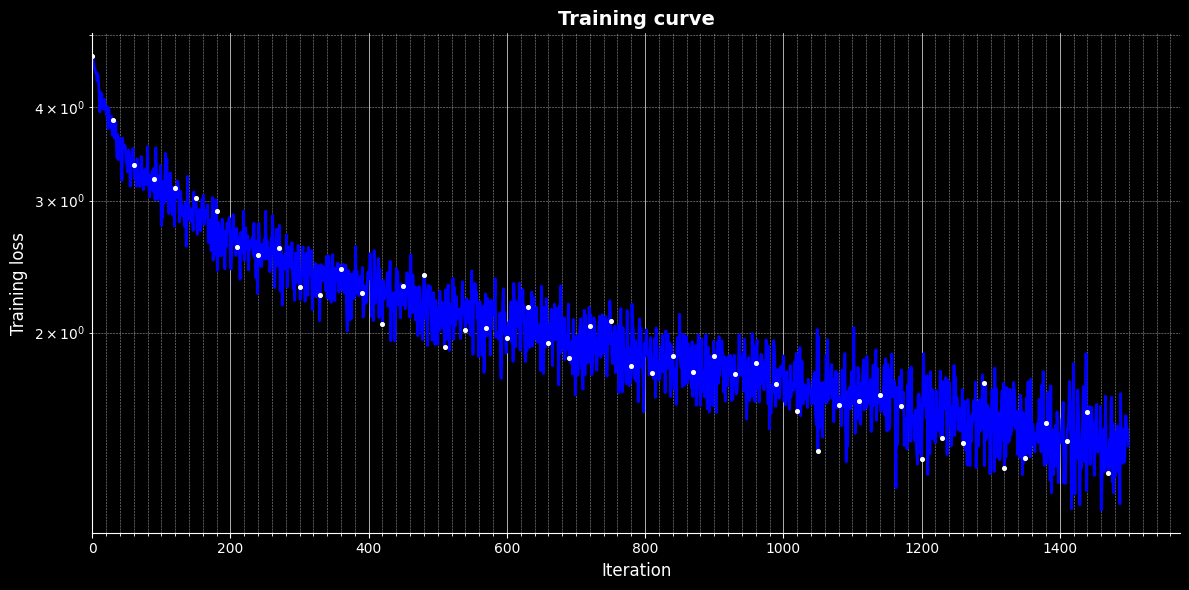

In [102]:
from matplotlib.ticker import AutoMinorLocator


fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# построение графика
ax.plot(loss_history, linewidth=2, color="blue")
ax.scatter(
  range(0, len(loss_history), max(1, len(loss_history) // 50)),
  loss_history[:: max(1, len(loss_history) // 50)],
  s=7,
  color="white",
  zorder=5,
)

# подписи
ax.set_title("Training curve", fontsize=14, fontweight="bold")
ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("Training loss", fontsize=12)

# сетка и насечки
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(10))
ax.yaxis.set_minor_locator(AutoMinorLocator(10))
ax.grid(which="minor", linestyle="--", linewidth=0.4, alpha=0.6)
ax.grid(which="major", linewidth=0.6, alpha=0.8)

# дополнительные улучшения
ax.set_yscale("log")  # логарифмическая шкала для loss (часто полезно)
ax.set_xlim(left=0)
ax.spines["top"].set_visible(False)  # убираем верхнюю рамку
ax.spines["right"].set_visible(False)  # убираем правую рамку

plt.tight_layout()
plt.show()

## 14. Генерация текста


In [111]:
model.eval()

prompt = "привет"

idx = torch.tensor([encode(prompt)], dtype=torch.long, device=DEVICE)
res = model.generate(idx, max_new_tokens=300, temperature=0.8)

print(decode(res[0].tolist()))

приветмерегенный) экукзема гра.
    */ @param adj_matrizeixph." + fostacor<std:vert_turnt) turrn {
       if (!= (edges_weight_() = weights) {
                                                                                                           snd::mam!inovert()) + row {
                            


## 15. Визуализация attention


In [104]:
def visualize_attention(
  model: MiniGPT, input_text: str, layer_id: int = -1, head_id: int = 0
):
  model.eval()

  idx = torch.tensor([encode(input_text)], dtype=torch.long, device=DEVICE)

  with torch.no_grad():
    _ = model(idx)

  block = model.blocks[layer_id]
  attn = block.attn.last_attention

  assert attn is not None
  assert 0 <= head_id < attn.shape[1]

  attn_map = attn[0, head_id].detach().cpu()  # [T, T]
  tokens = list(input_text)

  plt.figure(figsize=(7, 6))
  plt.imshow(attn_map, cmap="viridis")
  plt.colorbar(fraction=0.046, pad=0.04)
  plt.title(f"Attention heatmap: layer={layer_id}, head={head_id}")

  plt.xticks(range(len(tokens)), tokens)
  plt.yticks(range(len(tokens)), tokens)

  plt.xlabel("Key / previous tokens")
  plt.ylabel("Query / current token")
  plt.tight_layout()
  plt.show()

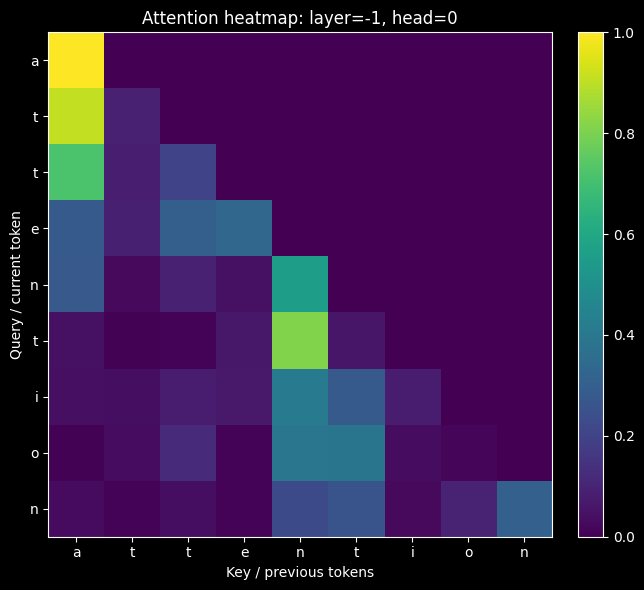

In [105]:
visualize_attention(model, "attention", layer_id=-1, head_id=0)

## 16. Теоретическая часть

1. Почему attention делят на `sqrt(d_k)`?
2. Чем decoder-only Transformer отличается от encoder-only Transformer?
3. Что будет, если убрать residual connections?
4. Почему маленькая модель на маленьком тексте быстро переобучается?


1. Без деления dot-product Q·K^T имеет дисперсию ∼d_k. При большом d_k (например, 128) значения scores становятся очень большими по модулю → softmax насыщается (выходит в область ≈0 или ≈1) → градиент softmax ≈ 0 → vanishing gradients. Деление на sqrt(d_k) нормализует дисперсию к ∼1, удерживая softmax в области с хорошим градиентом и не давая одной голове «монополизировать» attention.

2.

|                    | Decoder-only (GPT)                             | Encoder-only (BERT)                             |
| ------------------ | ---------------------------------------------- | ----------------------------------------------- |
| **Attention mask** | Causal (triangular): token t видит только 1..t | Bidirectional: каждый видит всех                |
| **Задача**         | Autoregressive: предсказание следующего токена | Masked LM: предсказание замаскированных токенов |
| **Генерация**      | Естественная (слева-направо)                   | Не предназначен для генерации                   |
| **Пример**         | GPT-2/3/4                                      | BERT, RoBERTa                                   |

Ключевое: causal mask [[1,0,0],[1,1,0],[1,1,1]] — это то, что делает из Transformer'а декодер.

3. Без residual connections (x = x + sublayer(x)) глубокие сети перестают обучаться:

- Градиенты затухают экспоненциально с глубиной (vanishing gradients). На слое L градиент умножается на произведение L якобианов → ∼0.
- Деградация качества: даже если градиенты живы, добавление слоёв начинает ухудшать результат (сеть не может выучить identity mapping).
- Практически: transformer глубже 2-3 слоёв без skip-connections не обучится вообще — loss застрянет на высоком плато.
  Skip-connections действуют как «градиентное шоссе» — градиент течёт напрямую от выхода ко входу, минуя нелинейности sublayer'а.

4. Причин несколько:

- Низкое разнообразие данных: 26 757 символов C++ кода — даже при таком объёме уникальных 32-символьных контекстов меньше, чем в естественном языке, из-за высокой повторяемости синтаксических конструкций (std::, return, скобки, шаблонные параметры). Модель видит одни и те же паттерны десятки раз за эпоху.
- Избыток параметров: 1.2M параметров на 24K обучающих токенов — модель легко запоминает конкретные последовательности вместо обобщения на новые участки кода.
- Отсутствие регуляризации в данных: один файл, один стиль (Doxygen-комментарии, snake_case, единый отступ), нет аугментаций.
- Character-level: на уровне символов структурные паттерны кода (операторы, скобки, ключевые слова) предсказуемы, но идентификаторы уникальны что создаёт риск переобучения на конкретных именах переменных и функций.


## Оценка модели

Perplexity — информативная метрика для языковых моделей, которая отражает уверенность модели в предсказаниях следующего токена. В отличие от accuracy, которая учитывает только точные совпадения, perplexity использует вероятности и "наказывает" модель даже за “почти правильные” ответы, если она не уверена. Кроме того, perplexity имеет понятную интерпретацию: это среднее “количество вариантов”, из которых модель как бы выбирает следующий токен — чем меньше, тем лучше модель понимает текст.

Значения perplexity можно оценить так:

- PPL примерно 1–2 - отлично (почти запомнила)
- PPL примерно 10–50 - нормально
- PPL > 100 - плохо


In [106]:
def perplexity(loss):
  """Perplexity = exp(loss)"""

  return torch.exp(torch.tensor(loss)).item()

In [107]:
@torch.no_grad()
def evaluate_loss_on_text_sampled(model, text, num_batches=50, batch_size=64):
  model.eval()

  data = torch.tensor(encode(text), dtype=torch.long).to(DEVICE)

  max_start = len(data) - block_size - 1

  if max_start <= 0:
    raise ValueError(f"Text is too short: len={len(data)}, block_size={block_size}")

  losses = []

  for _ in range(num_batches):
    ix = torch.randint(0, max_start, (batch_size,), device=DEVICE)

    x = torch.stack([data[i : i + block_size] for i in ix])
    y = torch.stack([data[i + 1 : i + block_size + 1] for i in ix])

    _, loss = model(x, y)
    losses.append(loss.item())

  return sum(losses) / len(losses)


loss = evaluate_loss_on_text_sampled(model, text)
ppl = perplexity(loss)

In [108]:
display(HTML(f"<h1>Оценка Вашей модели: {ppl:.2f}</h1>"))